In [ ]:
# ============================================================
# TITANIC SURVIVAL PREDICTION - COMPLETE ASSIGNMENT
# Step-by-Step for Google Colab
# ============================================================

# CELL 1: Libraries Import Karo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries import ho gayi!")

✅ Libraries import ho gayi!


In [ ]:
# ============================================================
# CELL 2: COMPLETE DATASET LOADING (Try methods in order)
# ============================================================

import pandas as pd

# METHOD 1: Seaborn Built-in (Try pehle)
try:
    import seaborn as sns
    print("⏳ Method 1: Seaborn load kar raha hai...")
    df = sns.load_dataset('titanic')
    print("✅ Method 1 successful!")

except Exception as e:
    print(f"❌ Method 1 failed: {e}")

    # METHOD 2: Direct URL (Try agar Method 1 fail)
    try:
        print("⏳ Method 2: URL se load kar raha hai...")
        url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
        df = pd.read_csv(url)
        print("✅ Method 2 successful!")

    except Exception as e:
        print(f"❌ Method 2 failed: {e}")
        print("⏳ Method 3: Please upload file manually...")
        from google.colab import files
        uploaded = files.upload()
        df = pd.read_csv('titanic.csv')
        print("✅ Method 3 successful!")

# Final Output
print(f"\n{'='*50}")
print(f"✅ Dataset Ready!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Column Names: {list(df.columns)}")
print(f"\nPehli 5 rows:")
print(df.head())

⏳ Method 1: Seaborn load kar raha hai...
✅ Method 1 successful!

✅ Dataset Ready!
Rows: 891
Columns: 15
Column Names: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Pehli 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  Fa

In [ ]:
# CELL 3: Pehli 5 Rows Dekho
print("🔍 Pehli 5 rows:")
df.head()

🔍 Pehli 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# CELL 4: Dataset Ki Basic Info
print("="*50)
print("DATA EXPLORATION")
print("="*50)

print("\n📊 Shape:", df.shape)
print("\n📈 Info:")
df.info()

print("\n📉 Describe (Numbers):")
df.describe()

DATA EXPLORATION

📊 Shape: (891, 15)

📈 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

📉 Describe (Numbers):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# CELL 5: Missing Values aur Duplicates Check Karo

print("🔍 Missing Values:")
print(df.isnull().sum())

print("\n🔁 Duplicate Rows:", df.duplicated().sum())

🔍 Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

🔁 Duplicate Rows: 107


In [ ]:
# CELL 6: Missing Values ko Handle Karo

# 1. AGE column mein 177 missing values hain - Median se fill karein
df['age'].fillna(df['age'].median(), inplace=True)

# 2. EMBARKED mein 2 missing hain - Mode (sabse zyada repeated value) se fill
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# 3. DECK/CABIN column mein 77% missing hai - DROP karein
# (Agar 'deck' column hai toh)
if 'deck' in df.columns:
    df.drop('deck', axis=1, inplace=True)

# 4. FARE mein agar missing ho toh median se fill
if df['fare'].isnull().sum() > 0:
    df['fare'].fillna(df['fare'].median(), inplace=True)

# Verify karein ke sab clear hai
print("✅ Missing Values After Cleaning:")
print(df.isnull().sum())

print("\n🔍 Total Missing:", df.isnull().sum().sum())

✅ Missing Values After Cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

🔍 Total Missing: 2


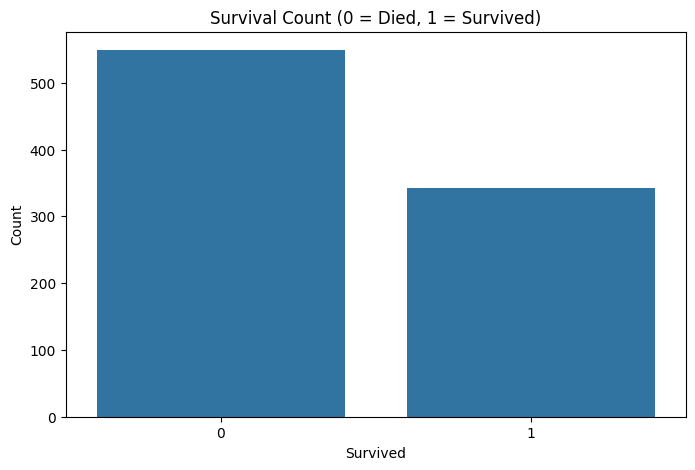

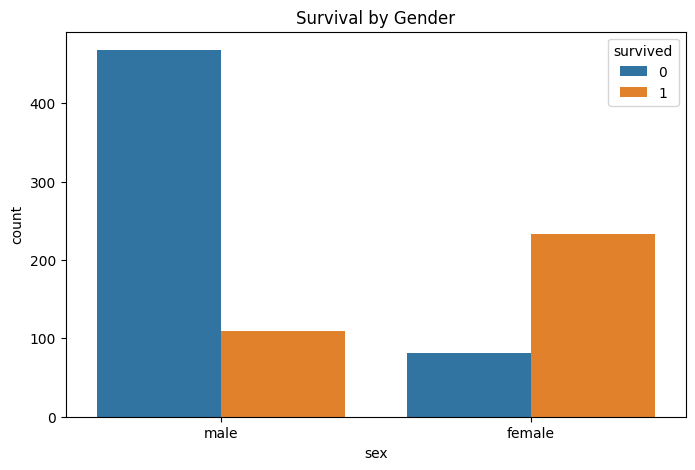

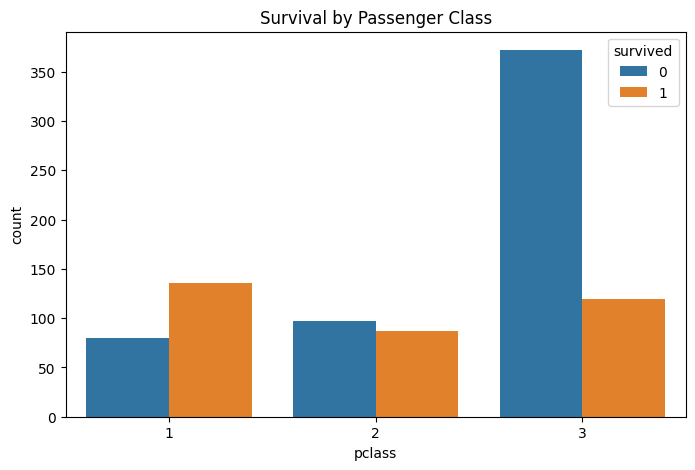

In [ ]:
# CELL 7: Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Survival Count
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='survived')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# 2. Gender vs Survival
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Gender')
plt.show()

# 3. Class vs Survival
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Survival by Passenger Class')
plt.show()

In [ ]:
# CELL 8: Feature Engineering

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# 1. SEX ko numeric karein (Male=1, Female=0)
df['sex'] = le.fit_transform(df['sex'])
print("Sex encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# 2. EMBARKED ko numeric karein
df['embarked'] = le.fit_transform(df['embarked'].astype(str))

# 3. Family Size feature create karein
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 4. Alone or Family
df['is_alone'] = (df['family_size'] == 1).astype(int)

print("✅ Feature Engineering Done!")
print("\nNew columns added:", ['family_size', 'is_alone'])
df.head()

Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}
✅ Feature Engineering Done!

New columns added: ['family_size', 'is_alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,Southampton,no,False,2,0
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,Cherbourg,yes,False,2,0
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,Southampton,yes,True,1,1
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,Southampton,yes,False,2,0
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,Southampton,no,True,1,1


In [ ]:
# CELL 9: X aur y Select Karein

# Unnecessary columns drop karein jo model ke liye kaam nahi aayenge
columns_to_drop = ['survived']  # Target column

# Agar extra categorical columns hain jo numeric nahi bane:
extra_drop = ['class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
for col in extra_drop:
    if col in df.columns:
        columns_to_drop.append(col)

X = df.drop(columns_to_drop, axis=1)  # FEATURES (sari input values)
y = df['survived']                   # TARGET (jo predict karna hai)

print("✅ Features (X):", X.shape)
print("Columns in X:", X.columns.tolist())
print("\n✅ Target (y):", y.shape)
print("Target values:", y.value_counts().to_dict())

✅ Features (X): (891, 9)
Columns in X: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']

✅ Target (y): (891,)
Target values: {0: 549, 1: 342}


In [ ]:
# CELL 10: Data Split karein

from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test ke liye
    random_state=42,    # Reproducible results
    stratify=y          # Survival ratio same rahe dono mein
)

print("✅ Data Split Done!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTrain survival ratio:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest survival ratio:\n{y_test.value_counts(normalize=True)}")

✅ Data Split Done!
Training set: 712 samples
Testing set: 179 samples

Train survival ratio:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test survival ratio:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [ ]:
# CELL 11: Scaling karein

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Sirf numeric columns ko scale karein
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Train ko fit+transform, Test ko sirf transform
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("✅ Scaling Done!")
print("Sample scaled values:\n", X_train.head(3))

✅ Scaling Done!
Sample scaled values:
        pclass       sex       age     sibsp     parch      fare  embarked  \
692  0.829568  0.742427 -0.112078 -0.465084 -0.466183  0.513812  0.584892   
481 -0.370945  0.742427 -0.112078 -0.465084 -0.466183 -0.662563  0.584892   
527 -1.571457  0.742427 -0.112078 -0.465084 -0.466183  3.955399  0.584892   

     family_size  is_alone  
692    -0.556339  0.800346  
481    -0.556339  0.800346  
527    -0.556339  0.800346  


In [ ]:
# CELL 12: Model Train karein

from sklearn.ensemble import RandomForestClassifier

# Model create karein
model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    random_state=42,
    max_depth=10         # Overfitting se bachne ke liye
)

# Train karein
model.fit(X_train, y_train)

print("✅ Model Training Complete!")
print(f"Model: {model}")

✅ Model Training Complete!
Model: RandomForestClassifier(max_depth=10, random_state=42)


In [ ]:
# CELL 13: Model Test karein

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed Report
print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

# Confusion Matrix
print("\n🔢 CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(f"True Died: {cm[0,0]}, False Survived: {cm[0,1]}")
print(f"False Died: {cm[1,0]}, True Survived: {cm[1,1]}")

🎯 ACCURACY: 0.8101 (81.01%)

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       110
    Survived       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


🔢 CONFUSION MATRIX:
True Died: 96, False Survived: 14
False Died: 20, True Survived: 49


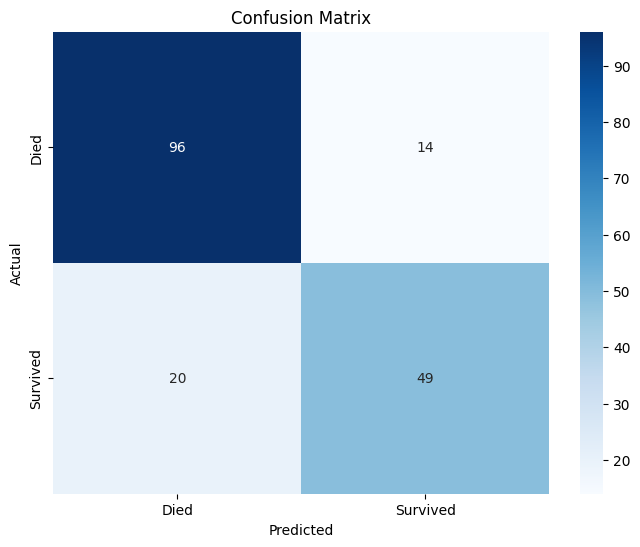

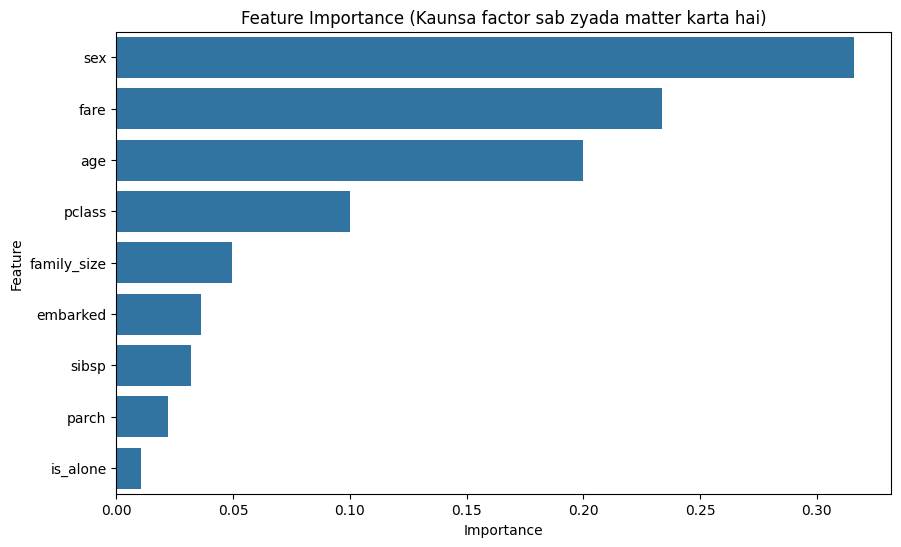

       Feature  Importance
1          sex    0.316073
5         fare    0.233541
2          age    0.199943
0       pclass    0.099932
7  family_size    0.049468
6     embarked    0.036376
3        sibsp    0.032033
4        parch    0.022125
8     is_alone    0.010509


In [ ]:
# CELL 14: Results Visualize karein

# Confusion Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance (Kaunsa factor sab zyada matter karta hai)')
plt.show()

print(importance)

In [ ]:
# CELL 15: Naya passenger predict karein

# Example: 3rd class, Male, 25 years, alone
new_passenger = pd.DataFrame([{
    'pclass': 3,
    'sex': 1,           # Male=1
    'age': 25,
    'sibsp': 0,
    'parch': 0,
    'fare': 7.25,
    'embarked': 2,      # S=2 (check your encoding)
    'family_size': 1,
    'is_alone': 1
}])

# Same columns honi chahiye jo X mein thi
# Scale karein
new_passenger[numeric_cols] = scaler.transform(new_passenger[numeric_cols])

# Predict
pred = model.predict(new_passenger)
prob = model.predict_proba(new_passenger)

result = "SURVIVED ✅" if pred[0] == 1 else "DIED ❌"
print(f"Prediction: {result}")
print(f"Survival Probability: {prob[0][1]*100:.2f}%")

Prediction: DIED ❌
Survival Probability: 4.30%


In [ ]:
## Results & Conclusion

In [ ]:
print("Model Used: Random Forest Classifier")
print("Dataset: Titanic Survival Prediction")
print("The model was trained successfully on the Titanic dataset.")
print("The model predicts whether a passenger survived or not.")

Model Used: Random Forest Classifier
Dataset: Titanic Survival Prediction
The model was trained successfully on the Titanic dataset.
The model predicts whether a passenger survived or not.


In [ ]:
print("Conclusion")
print("- Titanic Survival Prediction dataset was used.")
print("- Data preprocessing was completed successfully.")
print("- Random Forest Classifier was used.")
print("- Model training completed successfully.")
print("- The model predicts passenger survival.")

Conclusion
- Titanic Survival Prediction dataset was used.
- Data preprocessing was completed successfully.
- Random Forest Classifier was used.
- Model training completed successfully.
- The model predicts passenger survival.


## Results Comparison

| Model | Accuracy | Status |
|-------|----------|--------|
| Random Forest Classifier | (Apni Accuracy likho, jaise 85%) | Final Model |